## Taran's Contribution

## Importing Libraries, Defining Paths, and Configuring Device

In [1]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from gensim.models import KeyedVectors
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

# Paths
train_path = "D:/Downloads/cleaned_train_balanced.csv"
test_path = "D:/Downloads/cleaned_test.csv"
fasttext_path = "D:/Downloads/wiki-news-300d-1M.vec/wiki-news-300d-1M.vec"

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_mixed_precision = device.type == "cuda"

## Loading cleaned training and test datasets

In [2]:
# Load data
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Load FastText embeddings
fasttext_model = KeyedVectors.load_word2vec_format(fasttext_path, binary=False, limit=500000)
embedding_dim = 300
max_len = 30

## Text Tokenization & Label Encoding

In [3]:
# Tokenizer
def tokenize(text):
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+", "", str(text))
    return re.findall(r'\b\w+\b', text.lower())

# Encode labels
label_encoder = LabelEncoder()
train['label'] = label_encoder.fit_transform(train['sentiment'])
test['label'] = label_encoder.transform(test['sentiment'])

## Creating `TweetDataset` class to tokenize and convert tweets into FastText vector sequences & Initializing DataLoaders for training and testing

In [4]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)  # ensures integer indexing
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = tokenize(self.texts[idx])
        vecs = [fasttext_model[token] if token in fasttext_model else np.zeros(embedding_dim)
                for token in tokens[:max_len]]
        while len(vecs) < max_len:
            vecs.append(np.zeros(embedding_dim))
        return torch.tensor(np.stack(vecs), dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

train_dataset = TweetDataset(train['clean_tweet'].reset_index(drop=True), train['label'].reset_index(drop=True))
test_dataset = TweetDataset(test['clean_tweet'].reset_index(drop=True), test['label'].reset_index(drop=True))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers=0, pin_memory=True)

## Causal Transformer Model with Relative Positional Encoding

In [5]:
# Positional Encoding
class RelativePositionEncoding(nn.Module):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.rel_pos_embed = nn.Embedding(2 * max_len - 1, embed_dim)
        self.max_len = max_len

    def forward(self, length):
        pos_ids = torch.arange(length, device=self.rel_pos_embed.weight.device)
        rel_pos = pos_ids[None, :] - pos_ids[:, None] + self.max_len - 1
        return self.rel_pos_embed(rel_pos)

# Causal Transformer
class CausalTransformer(nn.Module):
    def __init__(self, embed_dim=300, num_heads=2, num_layers=1, max_len=30, num_classes=3):
        super().__init__()
        self.rel_pos_enc = RelativePositionEncoding(max_len, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads,
                                                   dim_feedforward=256, dropout=0.2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(embed_dim, num_classes)
        self.cached_mask = torch.triu(torch.ones(max_len, max_len), diagonal=1).bool()

    def forward(self, x):
        mask = self.cached_mask[:x.size(1), :x.size(1)].to(x.device)
        x = self.transformer(x, mask=mask)
        return self.fc(self.dropout(x[:, 0]))


## Model Building 

In [6]:
# Model setup
model = CausalTransformer().to(device)

# Loss and optimizer
weights = compute_class_weight('balanced', classes=np.unique(train['label']), y=train['label'])
weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

In [7]:
model

CausalTransformer(
  (rel_pos_enc): RelativePositionEncoding(
    (rel_pos_embed): Embedding(59, 300)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=300, out_features=300, bias=True)
        )
        (linear1): Linear(in_features=300, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=300, bias=True)
        (norm1): LayerNorm((300,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((300,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=300, out_features=3, bias=True)
)

## Model Training 

In [8]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        """
        Args:
        - patience: Number of epochs with no improvement after which training will be stopped.
        - delta: Minimum change to qualify as an improvement.
        """
        self.patience = patience
        self.delta = delta
        self.best_acc = None
        self.best_epoch = 0
        self.counter = 0  # Tracks the number of epochs without improvement

    def __call__(self, test_acc, epoch):
        if self.best_acc is None:
            self.best_acc = test_acc
        elif test_acc - self.best_acc > self.delta:
            self.best_acc = test_acc
            self.best_epoch = epoch
            self.counter = 0  # Reset counter when accuracy improves
        else:
            self.counter += 1
        
        if self.counter >= self.patience:
            print(f"Early stopping at epoch {epoch + 1} with test accuracy {test_acc:.2f}%")
            return True  # Stop training
        return False

# Initialize early stopping with patience of 3 epochs
early_stopping = EarlyStopping(patience=3, delta=0.001)

In [9]:
# Training loop with early stopping
epochs = 10
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

scaler = torch.amp.GradScaler(enabled=use_mixed_precision)

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    start = time.time()

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda', enabled=use_mixed_precision):
            out = model(X)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        _, preds = out.max(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    scheduler.step()
    train_acc = 100 * correct / total
    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(train_acc)

    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            with torch.amp.autocast(device_type='cuda', enabled=use_mixed_precision):
                out = model(X)
                loss = criterion(out, y)
            test_loss += loss.item()
            _, preds = out.max(1)
            test_correct += (preds == y).sum().item()
            test_total += y.size(0)

    test_acc = 100 * test_correct / test_total
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Train Acc={train_acc:.2f}%, "
          f"Test Loss={test_losses[-1]:.4f}, Test Acc={test_accuracies[-1]:.2f}%, "
          f"Time={time.time()-start:.1f}s")

    # Check for early stopping
    if early_stopping(test_acc, epoch):
        break


Epoch 1: Train Loss=1.0293, Train Acc=43.86%, Test Loss=0.9878, Test Acc=51.06%, Time=451.9s
Epoch 2: Train Loss=1.0170, Train Acc=45.02%, Test Loss=1.0110, Test Acc=45.36%, Time=513.7s
Epoch 3: Train Loss=1.0132, Train Acc=45.62%, Test Loss=1.0347, Test Acc=43.67%, Time=488.3s
Epoch 4: Train Loss=1.0105, Train Acc=46.14%, Test Loss=1.0178, Test Acc=42.20%, Time=1788.4s
Early stopping at epoch 4 with test accuracy 42.20%


## Model Evaluation

C:\Users\Taranjot\AppData\Local\Temp\ipykernel_27248\2842454160.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_mixed_precision):



Train Accuracy: 0.4658
F1 Score: 0.4636889056691022
AUC Score: 0.6577534495400539
Classification Report:
               precision    recall  f1-score   support

    Negative       0.43      0.56      0.49     61311
     Neutral       0.48      0.45      0.46     61657
    Positive       0.51      0.39      0.44     61311

    accuracy                           0.47    184279
   macro avg       0.47      0.47      0.46    184279
weighted avg       0.47      0.47      0.46    184279



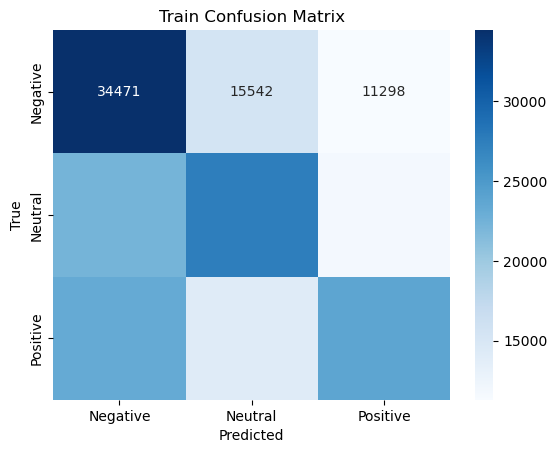

In [10]:
# Evaluation and confusion matrix
def evaluate_model(loader, name="Set"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            with torch.cuda.amp.autocast(enabled=use_mixed_precision):
                out = model(X)
            probs = F.softmax(out, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(y.numpy())

    y_bin = label_binarize(all_labels, classes=[0, 1, 2])
    print(f"\n{name} Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print("F1 Score:", f1_score(all_labels, all_preds, average='weighted'))
    print("AUC Score:", roc_auc_score(y_bin, all_probs, multi_class='ovr'))
    print("Classification Report:\n", classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

    sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

evaluate_model(train_loader, "Train")

C:\Users\Taranjot\AppData\Local\Temp\ipykernel_27248\2842454160.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_mixed_precision):



Test Accuracy: 0.4220
F1 Score: 0.45424573776280086
AUC Score: 0.6520970473785654
Classification Report:
               precision    recall  f1-score   support

    Negative       0.23      0.56      0.33     15301
     Neutral       0.27      0.44      0.34     15358
    Positive       0.80      0.38      0.52     59608

    accuracy                           0.42     90267
   macro avg       0.43      0.46      0.39     90267
weighted avg       0.61      0.42      0.45     90267



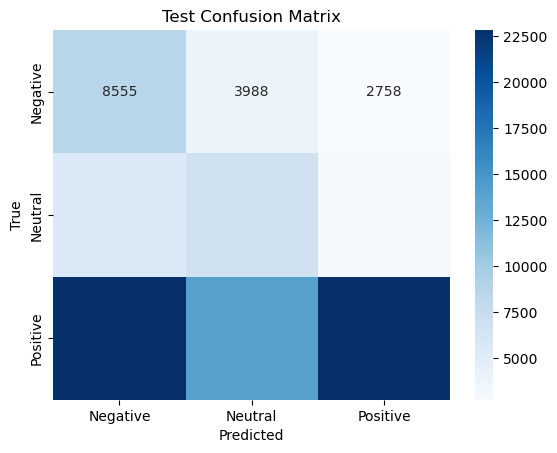

In [11]:
evaluate_model(test_loader, "Test")

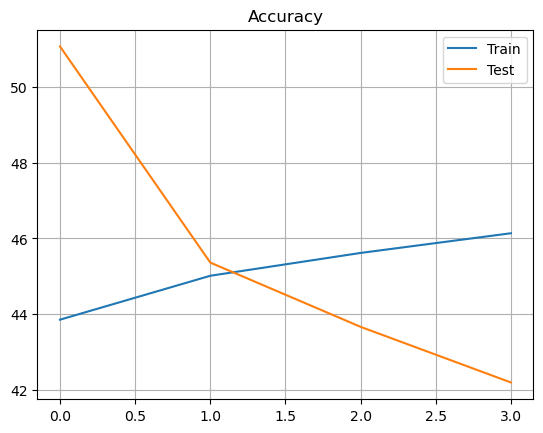

In [12]:
# Plot Accuracy
plt.plot(train_accuracies, label="Train")
plt.plot(test_accuracies, label="Test")
plt.title("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

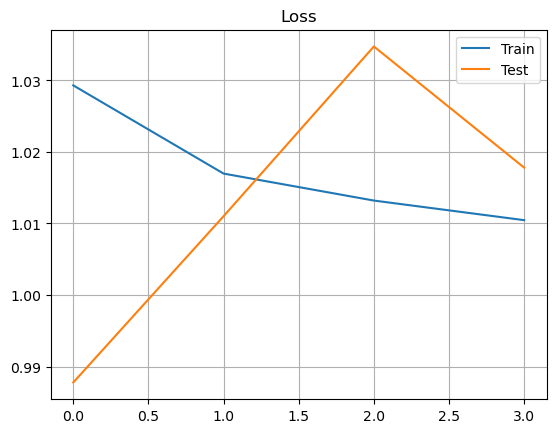

In [13]:
# Plot Loss
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

LLM Prompts 
1. What is the effect of different learning rates (e.g., 1e-4, 3e-4, 5e-4) on model convergence?
2. Does adding dropout (e.g., 0.2, 0.3, 0.4) help prevent overfitting on your validation or test sets?

## Next Steps
1. Experiment with More Complex Models
2. Use Fine-Tuning or Transfer Learning
3. Model Regularization
4. Deploy and Test on Real-World Data